# Метод опорных векторов: SVM и SVR (sklearn)

SVM строит разделяющую гиперплоскость с максимальным зазором между классами;
решение опирается только на часть объектов — опорные векторы. Здесь, в отличие
от соседних ноутбуков, используются готовые реализации sklearn (`LinearSVC`, `SVC`,
`SVR`), а вокруг них — мой код для метрик и визуализаций.

Содержание:

1. Бинарная классификация через `LinearSVC`;
2. `SVC` с линейным ядром и опорные векторы;
3. Многоклассовая классификация (3 класса);
4. Метрики качества: accuracy, precision, recall, $F_1$, $F_\beta$;
5. SVR — метод опорных векторов в задаче восстановления регрессии.


## 1. Бинарная классификация через LinearSVC

Два класса объектов по двум признакам. После обучения собираю вектор весов
$w = (w_0, w_1, w_2)$ из `intercept_` и `coef_` и считаю предсказания самостоятельно
через $\mathrm{sign}(w^{\top} x)$ — так видно, что модель внутри действительно
линейная.


In [1]:
import numpy as np
from sklearn import svm
import matplotlib.pyplot as plt

data_x = [(4.9, 3.3), (5.6, 4.5), (6.4, 4.3), (6.7, 5.7), (6.3, 5.0), (5.2, 3.9), (5.5, 3.7), (5.6, 3.6), (5.5, 3.8), (6.1, 4.7), (7.4, 6.1), (6.0, 5.1), (5.5, 4.4), (5.9, 5.1), (6.5, 5.8), (6.5, 4.6), (6.7, 4.4), (6.3, 5.6), (5.9, 4.8), (6.0, 4.5), (5.6, 4.1), (5.6, 4.9), (4.9, 4.5), (6.2, 4.5), (6.1, 4.7), (6.1, 4.9), (6.2, 5.4), (5.7, 4.2), (6.1, 5.6), (5.8, 4.0), (6.6, 4.6), (5.6, 4.2), (7.2, 6.1), (7.7, 6.7), (5.6, 3.9), (7.7, 6.9), (6.0, 4.0), (6.1, 4.0), (7.6, 6.6), (5.1, 3.0), (6.3, 6.0), (6.7, 5.7), (6.8, 5.9), (6.4, 5.5), (7.0, 4.7), (5.8, 5.1), (5.8, 5.1), (6.4, 5.3), (6.3, 4.9), (6.4, 5.3), (5.7, 3.5), (7.2, 5.8), (6.4, 5.6), (5.7, 4.5), (6.0, 4.5), (7.7, 6.1), (6.2, 4.3), (7.1, 5.9), (7.3, 6.3), (5.0, 3.3), (6.3, 5.1), (5.8, 3.9), (6.4, 4.5), (6.3, 5.6), (6.8, 5.5), (6.9, 5.4), (5.5, 4.0), (5.7, 4.1), (6.5, 5.5), (6.3, 4.7), (5.0, 3.5), (6.7, 5.8), (6.9, 4.9), (7.7, 6.7), (5.8, 4.1), (6.4, 5.6), (6.7, 5.2), (6.7, 4.7), (5.4, 4.5), (6.8, 4.8), (5.7, 4.2), (5.5, 4.0), (6.3, 4.9), (6.5, 5.2), (5.8, 5.1), (6.0, 4.8), (6.2, 4.8), (6.5, 5.1), (7.9, 6.4), (6.7, 5.0), (6.7, 5.6), (6.0, 5.0), (6.1, 4.6), (5.7, 5.0), (7.2, 6.0), (6.3, 4.4), (5.9, 4.2), (6.9, 5.1), (6.6, 4.4), (6.9, 5.7)]
data_y = [-1, -1, -1, 1, 1, -1, -1, -1, -1, -1, 1, -1, -1, 1, 1, -1, -1, 1, -1, -1, -1, 1, 1, -1, -1, 1, 1, -1, 1, -1, -1, -1, 1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, -1, -1, 1, -1, 1, 1, -1, 1, -1, -1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, 1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, 1, -1, 1]

# обучающая выборка в формате [1, x1, x2]
x_train = np.array([[1] + list(x) for x in data_x])
y_train = np.array(data_y)


In [2]:
model = svm.LinearSVC(max_iter=10000)  # с запасом, чтобы не ловить ConvergenceWarning
model.fit(data_x, data_y)

# в исходной версии веса собирались некорректно ([w1*w3, w2, w3]);
# правильная сборка: свободный член из intercept_, остальные из coef_
w = np.array([model.intercept_[0], model.coef_[0][0], model.coef_[0][1]])

y_pred = np.sign(x_train @ w)
Q = np.sum(y_train != y_pred)
print(f"веса w = {np.round(w, 3)}")
print(f"ошибок: {Q} из {len(y_train)}, accuracy: {np.mean(y_train == y_pred):.4f}")


веса w = [-2.414 -1.142  1.951]
ошибок: 6 из 100, accuracy: 0.9400


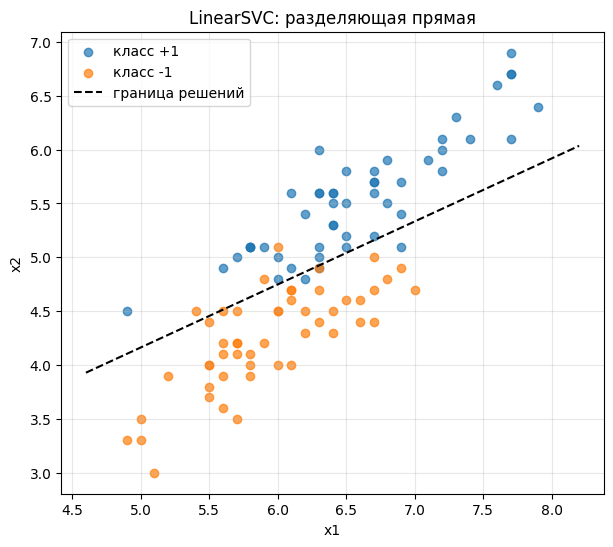

In [3]:
plt.figure(figsize=(7, 6))
pos = y_train == 1
plt.scatter(x_train[pos, 1], x_train[pos, 2], label="класс +1", alpha=0.7)
plt.scatter(x_train[~pos, 1], x_train[~pos, 2], label="класс -1", alpha=0.7)

# разделяющая прямая: w0 + w1*x1 + w2*x2 = 0
x_line = np.linspace(x_train[:, 1].min() - 0.3, x_train[:, 1].max() + 0.3, 100)
plt.plot(x_line, -(w[0] + w[1] * x_line) / w[2], "k--", label="граница решений")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LinearSVC: разделяющая прямая")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 2. SVC с линейным ядром: опорные векторы

Та же задача на втором наборе данных, но через `svm.SVC(kernel="linear")` — он
дополнительно возвращает опорные векторы: объекты, лежащие на границе зазора или
внутри него. Именно они одни определяют положение гиперплоскости.


In [19]:
data_x = [(3.0, 4.9), (2.7, 3.9), (3.0, 5.5), (2.6, 4.0), (2.9, 4.3), (3.1, 5.1), (2.2, 4.5), (2.3, 3.3), (2.7, 5.1), (3.3, 5.7), (2.8, 5.1), (2.8, 4.9), (2.5, 4.5), (2.8, 4.7), (3.2, 4.7), (3.2, 5.7), (2.8, 6.1), (3.6, 6.1), (2.8, 4.8), (2.9, 4.5), (3.1, 4.9), (2.3, 4.4), (3.3, 6.0), (2.6, 5.6), (3.0, 4.4), (2.9, 4.7), (2.8, 4.0), (2.5, 5.8), (2.4, 3.3), (2.8, 6.7), (3.0, 5.1), (2.3, 4.0), (3.1, 5.5), (2.8, 4.8), (2.7, 5.1), (2.5, 4.0), (3.1, 4.4), (3.8, 6.7), (3.1, 5.6), (3.1, 4.7), (3.0, 5.8), (3.0, 5.2), (3.0, 4.5), (2.7, 4.9), (3.0, 6.6), (2.9, 4.6), (3.0, 4.6), (2.6, 3.5), (2.7, 5.1), (2.5, 5.0), (2.0, 3.5), (3.2, 5.9), (2.5, 5.0), (3.4, 5.6), (3.4, 4.5), (3.2, 5.3), (2.2, 4.0), (2.2, 5.0), (3.3, 4.7), (2.7, 4.1), (2.4, 3.7), (3.0, 4.2), (3.2, 6.0), (3.0, 4.2), (3.0, 4.5), (2.7, 4.2), (2.5, 3.0), (2.8, 4.6), (2.9, 4.2), (3.1, 5.4), (2.5, 4.9), (3.2, 5.1), (2.8, 4.5), (2.8, 5.6), (3.4, 5.4), (2.7, 3.9), (3.0, 6.1), (3.0, 5.8), (3.0, 4.1), (2.5, 3.9), (2.4, 3.8), (2.6, 4.4), (2.9, 3.6), (3.3, 5.7), (2.9, 5.6), (3.0, 5.2), (3.0, 4.8), (2.7, 5.3), (2.8, 4.1), (2.8, 5.6), (3.2, 4.5), (3.0, 5.9), (2.9, 4.3), (2.6, 6.9), (2.8, 5.1), (2.9, 6.3), (3.2, 4.8), (3.0, 5.5), (3.0, 5.0), (3.8, 6.4)]
data_y = [1, -1, 1, -1, -1, 1, -1, -1, -1, 1, 1, 1, 1, -1, -1, 1, 1, 1, -1, -1, -1, -1, 1, 1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, 1, -1, -1, 1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, 1, 1, 1, -1, 1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1, -1, 1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1]

x_train = np.array([[1] + list(x) for x in data_x])
y_train = np.array(data_y)


In [20]:
clf = svm.SVC(kernel="linear")
clf.fit(data_x, data_y)  # обучаем на исходных признаках (без столбца единиц)

# коэффициенты разделяющей гиперплоскости
w0 = clf.intercept_[0]          # смещение
w1, w2 = clf.coef_[0]           # веса при x1, x2
w = np.array([w0, w1, w2])

# опорные векторы
v_support = clf.support_vectors_
print(f"опорных векторов: {len(v_support)} из {len(data_x)}")

# число ошибок на обучающей выборке
y_pred = np.sign(x_train @ w)
Q = np.sum(y_train != y_pred)
print(f"ошибок: {Q} из {len(y_train)}, accuracy: {np.mean(y_train == y_pred):.4f}")


опорных векторов: 66 из 100
ошибок: 22 из 100, accuracy: 0.7800


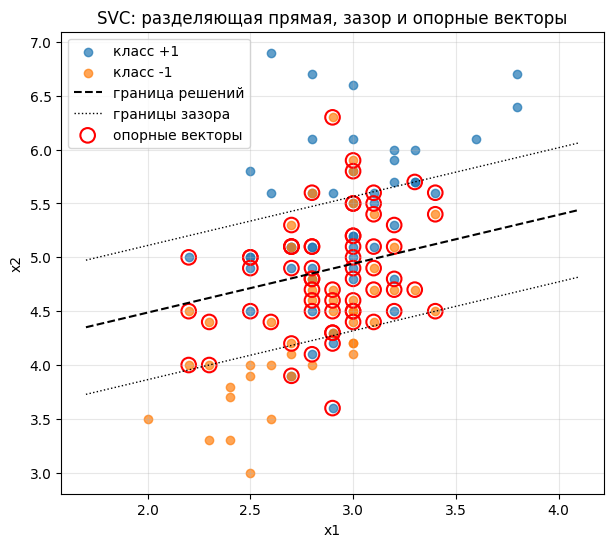

In [21]:
plt.figure(figsize=(7, 6))
pos = y_train == 1
plt.scatter(x_train[pos, 1], x_train[pos, 2], label="класс +1", alpha=0.7)
plt.scatter(x_train[~pos, 1], x_train[~pos, 2], label="класс -1", alpha=0.7)

x_line = np.linspace(x_train[:, 1].min() - 0.3, x_train[:, 1].max() + 0.3, 100)
plt.plot(x_line, -(w0 + w1 * x_line) / w2, "k--", label="граница решений")
# границы зазора: w0 + w1*x1 + w2*x2 = ±1
plt.plot(x_line, -(w0 - 1 + w1 * x_line) / w2, "k:", lw=1, label="границы зазора")
plt.plot(x_line, -(w0 + 1 + w1 * x_line) / w2, "k:", lw=1)

plt.scatter(v_support[:, 0], v_support[:, 1], s=110, facecolors="none",
            edgecolors="red", linewidths=1.5, label="опорные векторы")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVC: разделяющая прямая, зазор и опорные векторы")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Опорные векторы лежат ровно на границах зазора — остальные объекты
на решение не влияют вообще. Это главное содержательное отличие SVM от, скажем,
логистической регрессии, где вклад вносят все точки.

## 3. Многоклассовая классификация (3 класса)

`SVC` из коробки делает многоклассовую классификацию по схеме «один против одного»:
для трёх классов строятся три попарные гиперплоскости, затем голосование.
Данные — три гауссовых облака по 500 объектов, разбиение 70/30.


In [18]:
from sklearn.model_selection import train_test_split

np.random.seed(0)

# параметры распределений трёх классов
r1, D1, mean1 = 0.6, 3.0, [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]
r2, D2, mean2 = 0.7, 2.0, [-3, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]
r3, D3, mean3 = 0.5, 1.0, [1, 2]
V3 = [[D3, D3 * r3], [D3 * r3, D3]]

N = 500
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T
x3 = np.random.multivariate_normal(mean3, V3, N).T

data_x = np.hstack([x1, x2, x3]).T
data_y = np.hstack([np.zeros(N), np.ones(N), np.ones(N) * 2])

x_train_m, x_test_m, y_train_m, y_test_m = train_test_split(
    data_x, data_y, random_state=123, test_size=0.3, shuffle=True)


In [8]:
clf_m = svm.SVC(kernel="linear")
clf_m.fit(x_train_m, y_train_m)
predict_m = clf_m.predict(x_test_m)

# коэффициенты трёх попарных гиперплоскостей
w1, w2, w3 = clf_m.coef_
w01, w02, w03 = clf_m.intercept_

Q = np.sum(y_test_m != predict_m)
print(f"ошибок на тесте: {Q} из {len(y_test_m)}")
print(f"accuracy: {np.mean(y_test_m == predict_m):.4f}")


ошибок на тесте: 21 из 450
accuracy: 0.9533


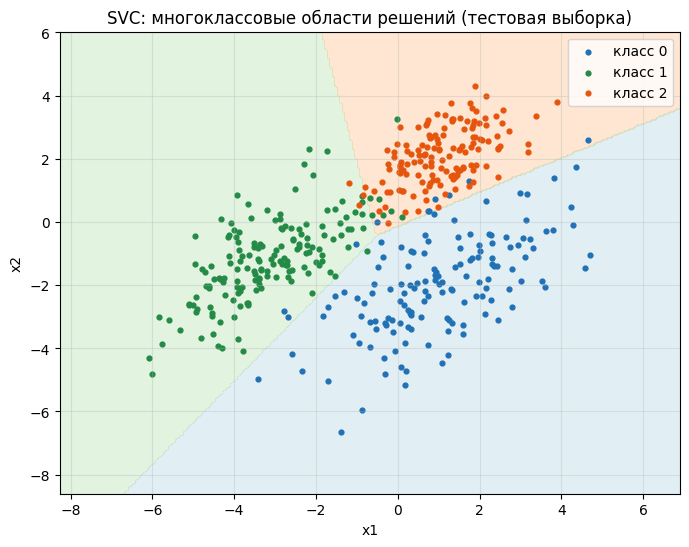

In [9]:
# области решений: прогоняем сетку через predict
gx = np.linspace(data_x[:, 0].min() - 1, data_x[:, 0].max() + 1, 250)
gy = np.linspace(data_x[:, 1].min() - 1, data_x[:, 1].max() + 1, 250)
G1, G2 = np.meshgrid(gx, gy)
Z = clf_m.predict(np.column_stack([G1.ravel(), G2.ravel()])).reshape(G1.shape)

plt.figure(figsize=(8, 6))
plt.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.3,
             colors=["#9ecae1", "#a1d99b", "#fdae6b"])
colors = ["#2171b5", "#238b45", "#e6550d"]
for c in range(3):
    pts = x_test_m[y_test_m == c]
    plt.scatter(pts[:, 0], pts[:, 1], s=12, c=colors[c], label=f"класс {c}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("SVC: многоклассовые области решений (тестовая выборка)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 4. Метрики: accuracy, precision, recall, F1 и F-бета

Два гауссовых класса с заметным перекрытием (2500 + 1500 объектов), разбиение 60/40.
Кроме accuracy считаю $P$, $R$, $F_1$ и $F_{\beta}$ с $\beta = 0.5$ — она сдвигает
важность в сторону precision:

$$F_\beta = \frac{(1 + \beta^2)\, P R}{\beta^2 P + R}$$


In [10]:
np.random.seed(0)

# параметры распределений классов
r1, D1, mean1 = 0.2, 3.0, [2, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]
r2, D2, mean2 = 0.5, 2.0, [-1, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

N1, N2 = 2500, 1500
x1 = np.random.multivariate_normal(mean1, V1, N1).T
x2 = np.random.multivariate_normal(mean2, V2, N2).T

data_x = np.hstack([x1, x2]).T
data_y = np.hstack([np.ones(N1) * -1, np.ones(N2)])

x_train, x_test, y_train, y_test = train_test_split(
    data_x, data_y, random_state=123, test_size=0.4, shuffle=True)

clf = svm.SVC(kernel="linear")
clf.fit(x_train, y_train)

w = np.array([clf.intercept_[0], clf.coef_[0][0], clf.coef_[0][1]])
predict = clf.predict(x_test)


In [11]:
TP = np.sum((predict == 1) & (y_test == 1))
TN = np.sum((predict == -1) & (y_test == -1))
FP = np.sum((predict == 1) & (y_test == -1))
FN = np.sum((predict == -1) & (y_test == 1))

accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

beta = 0.5
F_b = (1 + beta ** 2) * (precision * recall) / (beta ** 2 * precision + recall)
F1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"accuracy:  {accuracy:.4f}")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"F1:        {F1:.4f}")
print(f"F(beta=0.5): {F_b:.4f}")


TP=520, TN=877, FP=121, FN=82
accuracy:  0.8731
precision: 0.8112
recall:    0.8638
F1:        0.8367
F(beta=0.5): 0.8212


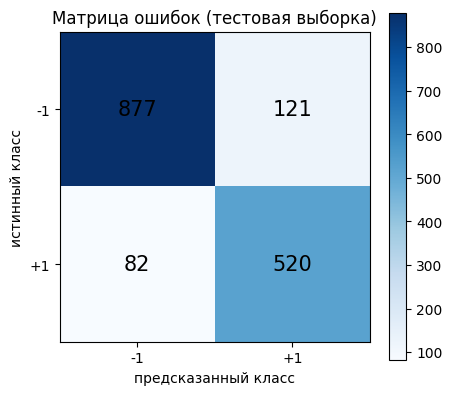

In [12]:
cm = np.array([[TN, FP], [FN, TP]])
plt.figure(figsize=(5, 4.5))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=15)
plt.xticks([0, 1], ["-1", "+1"])
plt.yticks([0, 1], ["-1", "+1"])
plt.xlabel("предсказанный класс")
plt.ylabel("истинный класс")
plt.title("Матрица ошибок (тестовая выборка)")
plt.colorbar()
plt.show()


## 5. SVR: метод опорных векторов в регрессии

SVR решает зеркальную задачу: подбирает функцию, которая отклоняется от обучающих
точек не больше, чем на $\varepsilon$ (точки внутри «трубки» не штрафуются).
Восстанавливаю функцию $f(x) = \sin 0.5x + 0.2\cos 2x - 0.1\sin 4x - 2.5$ моделью
с базисом $[1, x, x^2, x^3, \cos x, \sin x]$.


In [13]:
def func(x):
    return np.sin(0.5 * x) + 0.2 * np.cos(2 * x) - 0.1 * np.sin(4 * x) - 2.5


def model(w, x):
    return (w[0] + w[1] * x + w[2] * x ** 2 + w[3] * x ** 3
            + w[4] * np.cos(x) + w[5] * np.sin(x))


# обучающая выборка
coord_x = np.arange(-4.0, 6.0, 0.1)
coord_y = func(coord_x)

x_train_r = np.array([[x, x ** 2, x ** 3, np.cos(x), np.sin(x)] for x in coord_x])
y_train_r = coord_y

svr = svm.SVR(kernel="linear")
svr.fit(x_train_r, y_train_r)

# веса: свободный член из intercept_, остальные из coef_
w0 = svr.intercept_[0]
w1, w2, w3, w4, w5 = svr.coef_[0]
w = np.array([w0, w1, w2, w3, w4, w5])

pred = w0 + x_train_r @ w[1:]
Q = np.mean((pred - y_train_r) ** 2)
print(f"MSE: {Q:.5f}")
print(f"веса: {np.round(w, 4)}")


MSE: 0.02499
веса: [-2.466   0.3723 -0.0054 -0.0082 -0.0827  0.2013]


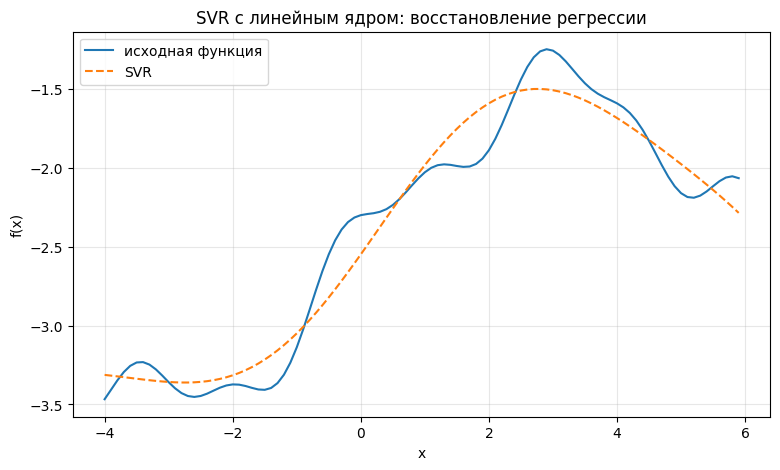

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(coord_x, coord_y, label="исходная функция")
plt.plot(coord_x, pred, "--", label="SVR")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("SVR с линейным ядром: восстановление регрессии")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Выводы

- Линейный SVM уверенно справляется с разделимыми и почти разделимыми выборками;
  веса модели легко извлекаются из `intercept_` и `coef_`, и дальше с ними можно
  работать как с обычным линейным классификатором.
- Опорных векторов оказалось заметно меньше, чем объектов выборки — решение
  и правда определяется малой частью данных.
- Многоклассовая классификация через «один против одного» работает прозрачно:
  три попарные гиперплоскости, итоговая accuracy на тесте высокая.
- Связка метрик precision/recall/$F_1$/$F_\beta$ информативнее голой accuracy,
  когда классы перекрываются или выборка несбалансирована (здесь 2500 против 1500).
- SVR с линейным ядром на подходящем базисе восстанавливает функцию с малым MSE;
  $\varepsilon$-трубка делает модель устойчивой к мелким отклонениям точек.
